In [1]:
!pip install pandas numpy matplotlib

oil spill           291
airplane accident   857
car accident        948
ice storm           608
wildfire            667
tornado             273
volcanic eruption   620
earthquake          908
flooded             941
nuclear explosion   232
collapsed           674
bicycle accident    229


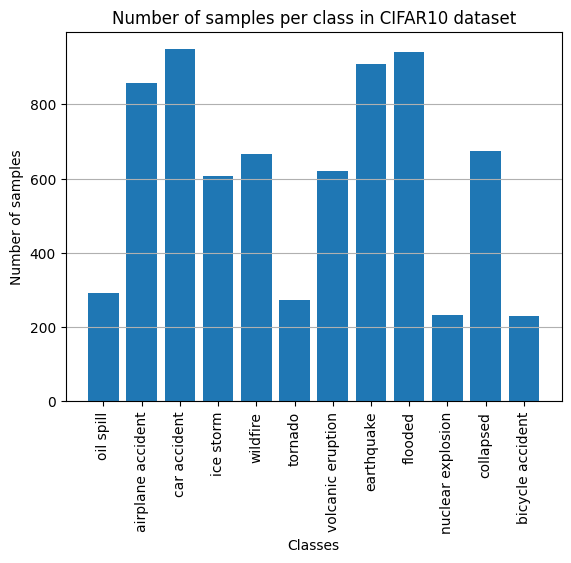

In [2]:
# inspect data: import images
#TODO: list classes + counts, check for imbalances, check image sizes, duplicates?(nah)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = 'Incidents-subset'
datasetClasses = os.listdir(dataset)
datasetCounts = []
for folder in datasetClasses:
    dir = os.listdir(dataset + "/" + folder)
    c = len(dir)
    datasetCounts.append(c)
    print('{}{}'.format(folder.ljust(20), c))

# make a histogram
plt.style.use('default')
fig, ax = plt.subplots()
ax.bar(datasetClasses, datasetCounts)
ax.set_xlabel('Classes')
ax.set_ylabel('Number of samples')
ax.set_title('Number of samples per class in CIFAR10 dataset')
plt.xticks(rotation=90)
plt.grid(axis = 'y')
plt.show()

# the dataset is imbalanced. Classes 'oil spill', 'tornado', 'nuclear explosion' & 'bicycle accident' are minority classes
# mediority: '','','',''
# majority class: '','','',''

In [3]:
from PIL import Image

dataset = 'Incidents-subset'
target_size = (224, 224)
image_extensions = {'.jpg', '.jpeg', '.png'}

images = []
labels = []
skipped = 0

for label in sorted(os.listdir(dataset)):
    label_dir = os.path.join(dataset, label)
    if not os.path.isdir(label_dir):
        continue
    for file_name in os.listdir(label_dir):
        if os.path.splitext(file_name)[1].lower() not in image_extensions:
            continue
        file_path = os.path.join(label_dir, file_name)
        try:
            with Image.open(file_path) as img:
                if img.mode == 'P':
                    img = img.convert('RGBA')
                img = img.convert('RGB')
                img = img.resize(target_size)
                images.append(np.array(img))
                labels.append(label)
        except Exception:
            skipped += 1
            print("Skipping:", file_path)

images = np.array(images)
labels = np.array(labels)

print(f'Loaded {len(images)} images, skipped {skipped} invalid files')
print(f'images shape: {images.shape}  dtype: {images.dtype}')
print(f'labels shape: {labels.shape}')
print(f'Classes: {sorted(set(labels))}')


Skipping: Incidents-subset/airplane accident/.hashed.6f95947e.desktop.story.share.jpg
Skipping: Incidents-subset/airplane accident/AR-190939882.jpg
Skipping: Incidents-subset/earthquake/.hashed.909e0e37.desktop.story.share.jpg
Skipping: Incidents-subset/flooded/.53_format=1.7777777777777777__image.jpg
Skipping: Incidents-subset/wildfire/wildfires-g.jpg
Loaded 7229 images, skipped 5 invalid files
images shape: (7229, 224, 224, 3)  dtype: uint8
labels shape: (7229,)
Classes: [np.str_('airplane accident'), np.str_('bicycle accident'), np.str_('car accident'), np.str_('collapsed'), np.str_('earthquake'), np.str_('flooded'), np.str_('ice storm'), np.str_('nuclear explosion'), np.str_('oil spill'), np.str_('tornado'), np.str_('volcanic eruption'), np.str_('wildfire')]
